# NB02B — validación puente de la arquitectura modal de NB03

### Proyecto: Simulación de speckle óptico mediante PINN-SIREN

**Objetivo.** Verificar, antes del campo aleatorio de NB03, que su arquitectura modal PINN-SIREN puede reproducir soluciones complejas conocidas de la ecuación de Helmholtz 2D cartesiana.

Este notebook se ubica en la cadena:

$$\boxed{\mathrm{NB01}\rightarrow\mathrm{NB02}\rightarrow\mathrm{NB02B}\rightarrow\mathrm{NB03}}$$

NB02B **no es todavía una simulación de speckle**. Es un experimento controlado que permite atribuir un posible fallo a la arquitectura modal, y no a la aleatoriedad del campo inicial.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = CURRENT if (CURRENT / 'scripts').exists() else CURRENT.parent
SCRIPT = PROJECT_ROOT / 'scripts' / 'experiments' / 'nb02b_modal_analytic_validation.py'
RESULTS = PROJECT_ROOT / 'results' / 'nb02b_modal_bridge'
SUMMARY = RESULTS / 'summary.json'

print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'Script reproducible: {SCRIPT}')
print(f'Resultados: {RESULTS}')

Raíz del proyecto: C:\roberto\Tesis_Maestria - codex
Script reproducible: C:\roberto\Tesis_Maestria - codex\scripts\experiments\nb02b_modal_analytic_validation.py
Resultados: C:\roberto\Tesis_Maestria - codex\results\nb02b_modal_bridge


## 1. Problema físico controlado

En coordenadas cartesianas normalizadas $(\tilde x,\tilde z)$ se resuelve

$$\boxed{\frac{\partial^2E}{\partial\tilde x^2}+\frac{\partial^2E}{\partial\tilde z^2}+\tilde k^2E=0},\qquad \tilde k=2\pi.$$

La solución de referencia es una superposición finita de ondas planas:

$$\boxed{E_{\mathrm{ref}}(\tilde x,\tilde z)=\sum_m A_m e^{i(\tilde k_{x,m}\tilde x+\tilde k_{z,m}\tilde z)}}.$$

Para cada modo se impone la relación de dispersión

$$\tilde k_{x,m}^2+\tilde k_{z,m}^2=\tilde k^2,$$

por lo que cada término y su suma satisfacen exactamente Helmholtz. Al combinar varios modos aparecen interferencias y una intensidad no uniforme, pero seguimos conociendo la respuesta exacta.

## 2. Reducción modal y conexión con NB03

Se escribe

$$E(\tilde x,\tilde z)=\sum_m a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x}.$$

Al sustituir en Helmholtz, cada coeficiente satisface

$$\boxed{a_m''(\tilde z)+\tilde k_{z,m}^2a_m(\tilde z)=0}.$$

La condición de onda que avanza hacia $+z$, con la convención temporal $e^{-i\omega t}$, proporciona

$$a_m(0)=A_m,\qquad a_m'(0)=i\tilde k_{z,m}A_m.$$

Estas son las únicas cantidades exactas entregadas al modelo. La solución completa se reserva para validación.

## 3. Condición de Cauchy dura

La salida física se construye como

$$a_{m,\theta}(\tilde z)=A_m+\tilde z\,i\tilde k_{z,m}A_m+\tilde z^2N_{m,\theta}(\tilde z).$$

Así, para cualquier valor de los pesos de la red,

$$a_{m,\theta}(0)=A_m,\qquad a_{m,\theta}'(0)=i\tilde k_{z,m}A_m.$$

No es necesario penalizar estas condiciones en la función de pérdida: quedan satisfechas por construcción.

## 4. Arquitectura que se está poniendo a prueba

Se importa directamente la clase `ModalSiren` utilizada por NB03. De esta manera no se crea una imitación aproximada de la arquitectura.

| Elemento | Configuración de NB03 |
|---|---:|
| Entrada | $\tilde z$ |
| Capas ocultas | 4 |
| Neuronas por capa | 128 |
| $\omega_{0,\mathrm{primera}}$ | 30 |
| $\omega_{0,\mathrm{interna}}$ | 1 |
| Salidas | partes real e imaginaria de todos los modos |
| Etiquetas interiores | 0 |

In [2]:
sys.path.insert(0, str(PROJECT_ROOT))
from scripts.experiments import nb03_modal_pinn_siren as nb03_arch

architecture = {
    'capas_ocultas': nb03_arch.NUM_LAYERS,
    'neuronas_por_capa': nb03_arch.HIDDEN_DIM,
    'omega_primera': nb03_arch.FIRST_OMEGA,
    'omega_interna': nb03_arch.HIDDEN_OMEGA,
}
pd.Series(architecture, name='valor').to_frame()

,valor
capas_ocultas,4.0
neuronas_por_capa,128.0
omega_primera,30.0
omega_interna,1.0


## 5. Escalera de dificultad

Se evalúan tres casos manteniendo la misma red:

| Caso | Interpretación |
|---:|---|
| 1 modo | Verifica una onda plana compleja |
| 5 modos | Verifica interferencia multimodal sencilla |
| 41 modos | Iguala la cantidad de modos complejos del NB03 actual |

El entrenamiento minimiza únicamente el residuo modal. La referencia analítica no participa en la optimización.

In [3]:
# Cambiar a True para repetir desde cero el entrenamiento completo.
FORCE_RETRAIN = False

def run_stage(**overrides):
    environment = os.environ.copy()
    environment.update({key: str(value) for key, value in overrides.items()})
    subprocess.run(
        [sys.executable, '-u', str(SCRIPT)], cwd=PROJECT_ROOT,
        env=environment, check=True,
    )

if FORCE_RETRAIN or not SUMMARY.exists():
    common = {
        'NB02B_CASE_COUNTS': '1,5,41',
        'NB02B_N_Z_EVAL': 301, 'NB02B_N_X_EVAL': 512,
    }
    # Etapa 1: exploración Adam desde pesos nuevos.
    run_stage(**common, NB02B_EPOCHS=2500, NB02B_N_Z_TRAIN=256,
              NB02B_LR='2e-4', NB02B_OPTIMIZER='adam',
              NB02B_RESUME_EXISTING=0)
    # Etapa 2: continuación Adam de baja tasa.
    run_stage(**common, NB02B_EPOCHS=6000, NB02B_N_Z_TRAIN=256,
              NB02B_LR='5e-5', NB02B_OPTIMIZER='adam',
              NB02B_RESUME_EXISTING=1)
    # Etapa 3: refinamiento físico L-BFGS con colocación fija.
    run_stage(**common, NB02B_EPOCHS=80, NB02B_N_Z_TRAIN=512,
              NB02B_OPTIMIZER='lbfgs', NB02B_LBFGS_INNER_ITER=20,
              NB02B_RESUME_EXISTING=1)
else:
    print('Se reutiliza la ejecución registrada. Use FORCE_RETRAIN=True para repetirla.')

Se reutiliza la ejecución registrada. Use FORCE_RETRAIN=True para repetirla.


## 6. Métricas independientes

La exactitud del campo complejo se mide con

$$L_E^2=\frac{\lVert E_\theta-E_{\mathrm{ref}}\rVert_2}{\lVert E_{\mathrm{ref}}\rVert_2}.$$

También se reportan coherencia compleja, intensidad, fase, residuo de Helmholtz y errores de Cauchy. Los criterios de aceptación del puente son:

$$L^2_{E,\mathrm{global}}<5\%,\qquad L^2_{E,\tilde z=1}<5\%,$$

$$\mathrm{coherencia}_{\tilde z=1}>0.90,\qquad \mathrm{RMSE}(R_E)<0.05.$$

In [4]:
with SUMMARY.open(encoding='utf-8') as stream:
    report = json.load(stream)

rows = []
for case in report['cases']:
    metric = case['metrics']
    rows.append({
        'modos': case['n_complex_modes'],
        'pasos acumulados': case['cumulative_recorded_epochs'],
        'L2 global (%)': 100 * metric['global_complex_relative_l2'],
        'L2 en z=1 (%)': 100 * metric['target_complex_relative_l2'],
        'coherencia z=1': metric['target_complex_coherence'],
        'residuo Helmholtz': metric['helmholtz_field_residual_normalized_rmse'],
        'Cauchy campo': metric['hard_cauchy_coefficient_rmse'],
        'Cauchy derivada': metric['hard_cauchy_derivative_rmse'],
        'tiempo (s)': case['training_seconds'],
        'aceptado': case['acceptance']['accepted'],
    })

results_table = pd.DataFrame(rows).set_index('modos')
results_table.round({
    'L2 global (%)': 4,
    'L2 en z=1 (%)': 4,
    'coherencia z=1': 6,
    'residuo Helmholtz': 6,
    'Cauchy campo': 9,
    'Cauchy derivada': 9,
    'tiempo (s)': 1,
})

,pasos acumulados,L2 global (%),L2 en z=1 (%),coherencia z=1,residuo Helmholtz,Cauchy campo,Cauchy derivada,tiempo (s),aceptado
modos,,,,,,,,,
1,8580,0.5262,0.4650,1.000000,0.021669,0.000000e+00,1.750000e-07,21.1,True
5,5570,2.1090,1.1306,0.999998,0.048746,9.000000e-09,6.700000e-08,16.5,True
41,5570,1.6369,0.5327,0.999992,0.036106,4.000000e-09,2.500000e-08,19.0,True


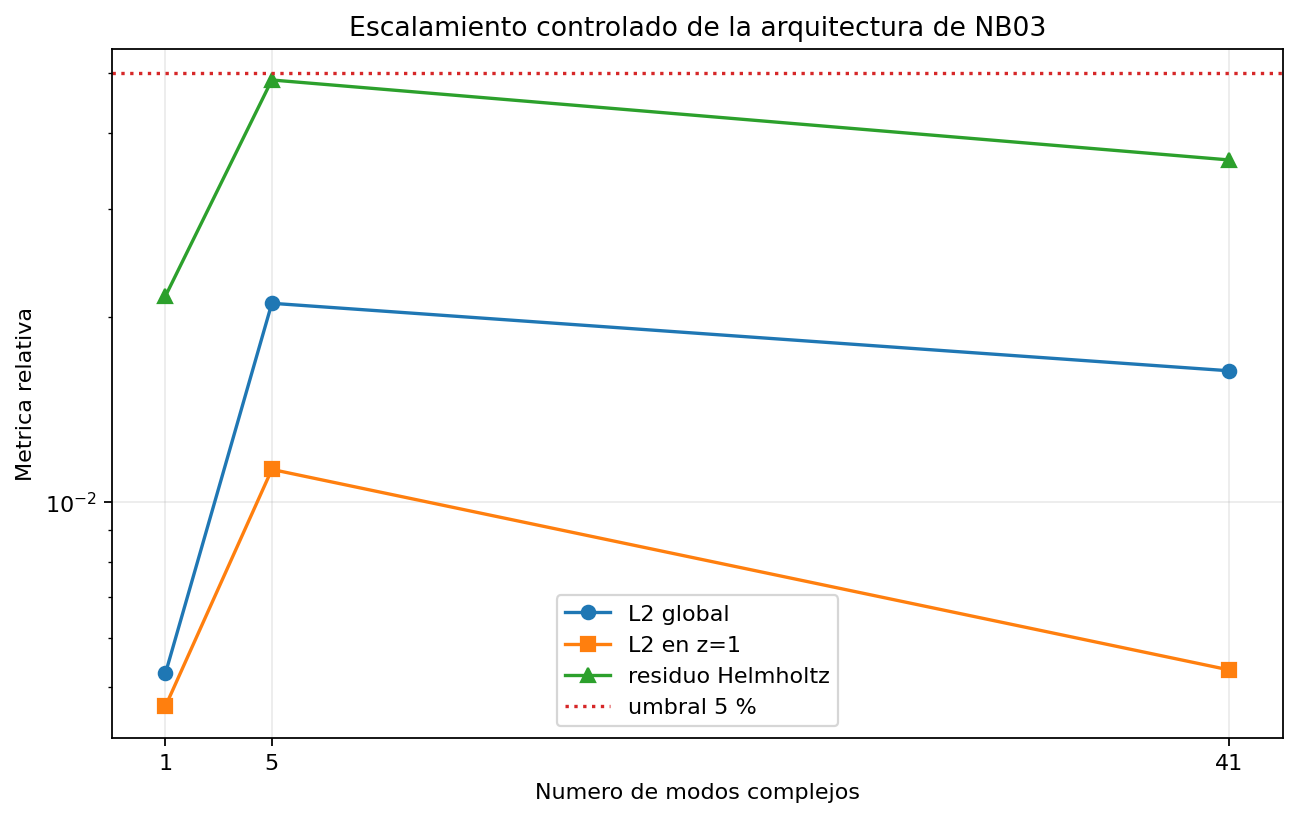

In [5]:
display(Image(filename=str(RESULTS / 'figures' / 'summary_modes.png')))

## 7. Inspección física por número de modos

Cada figura contiene: intensidad analítica y predicha en $\tilde z=1$; error complejo a lo largo de la propagación; mapa $I(\tilde x,\tilde z)$; y evolución de la pérdida física.

Caso: 1 modo(s)


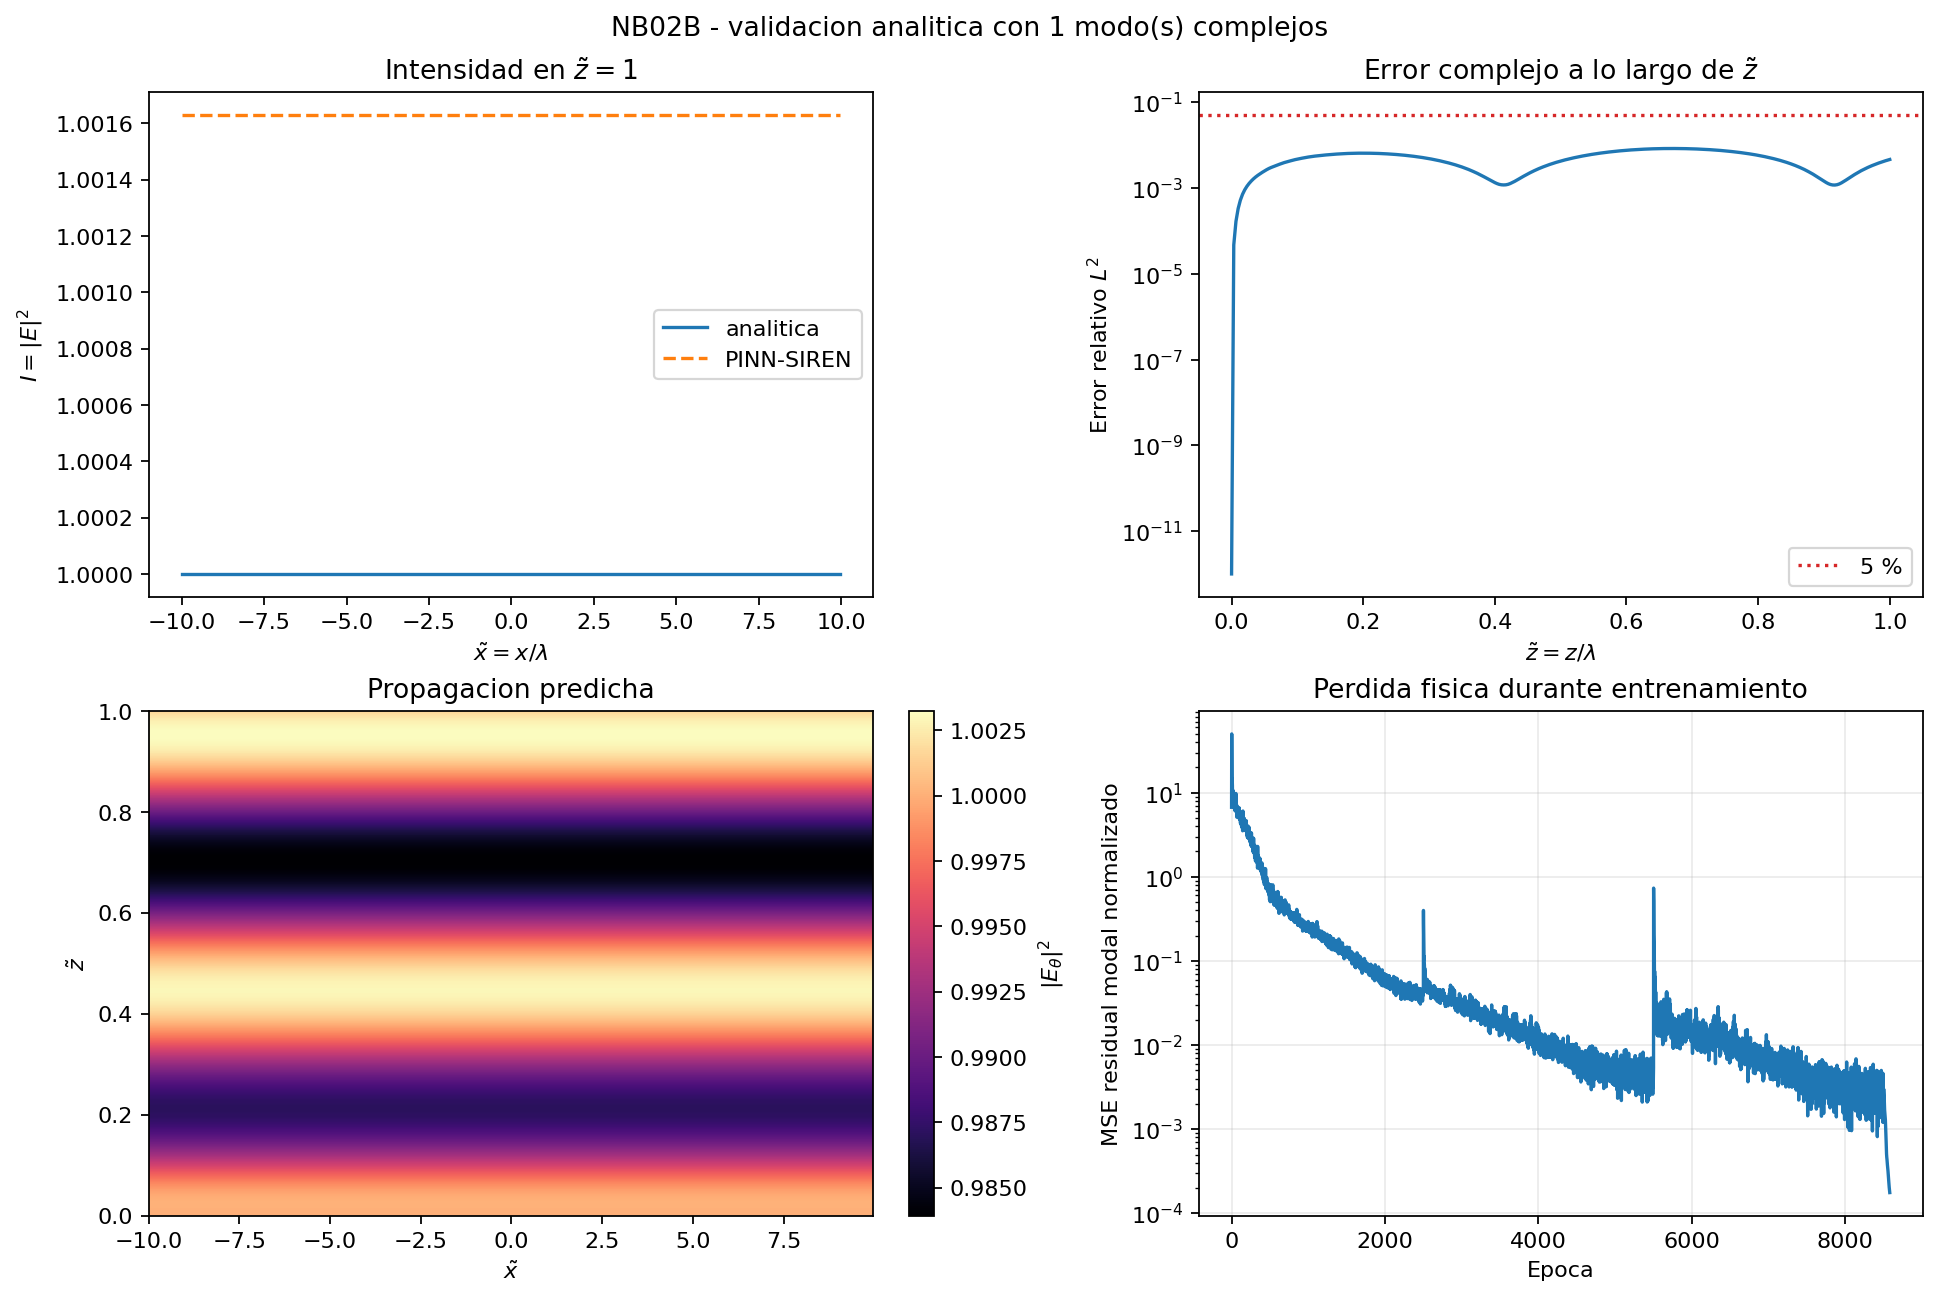

Caso: 5 modo(s)


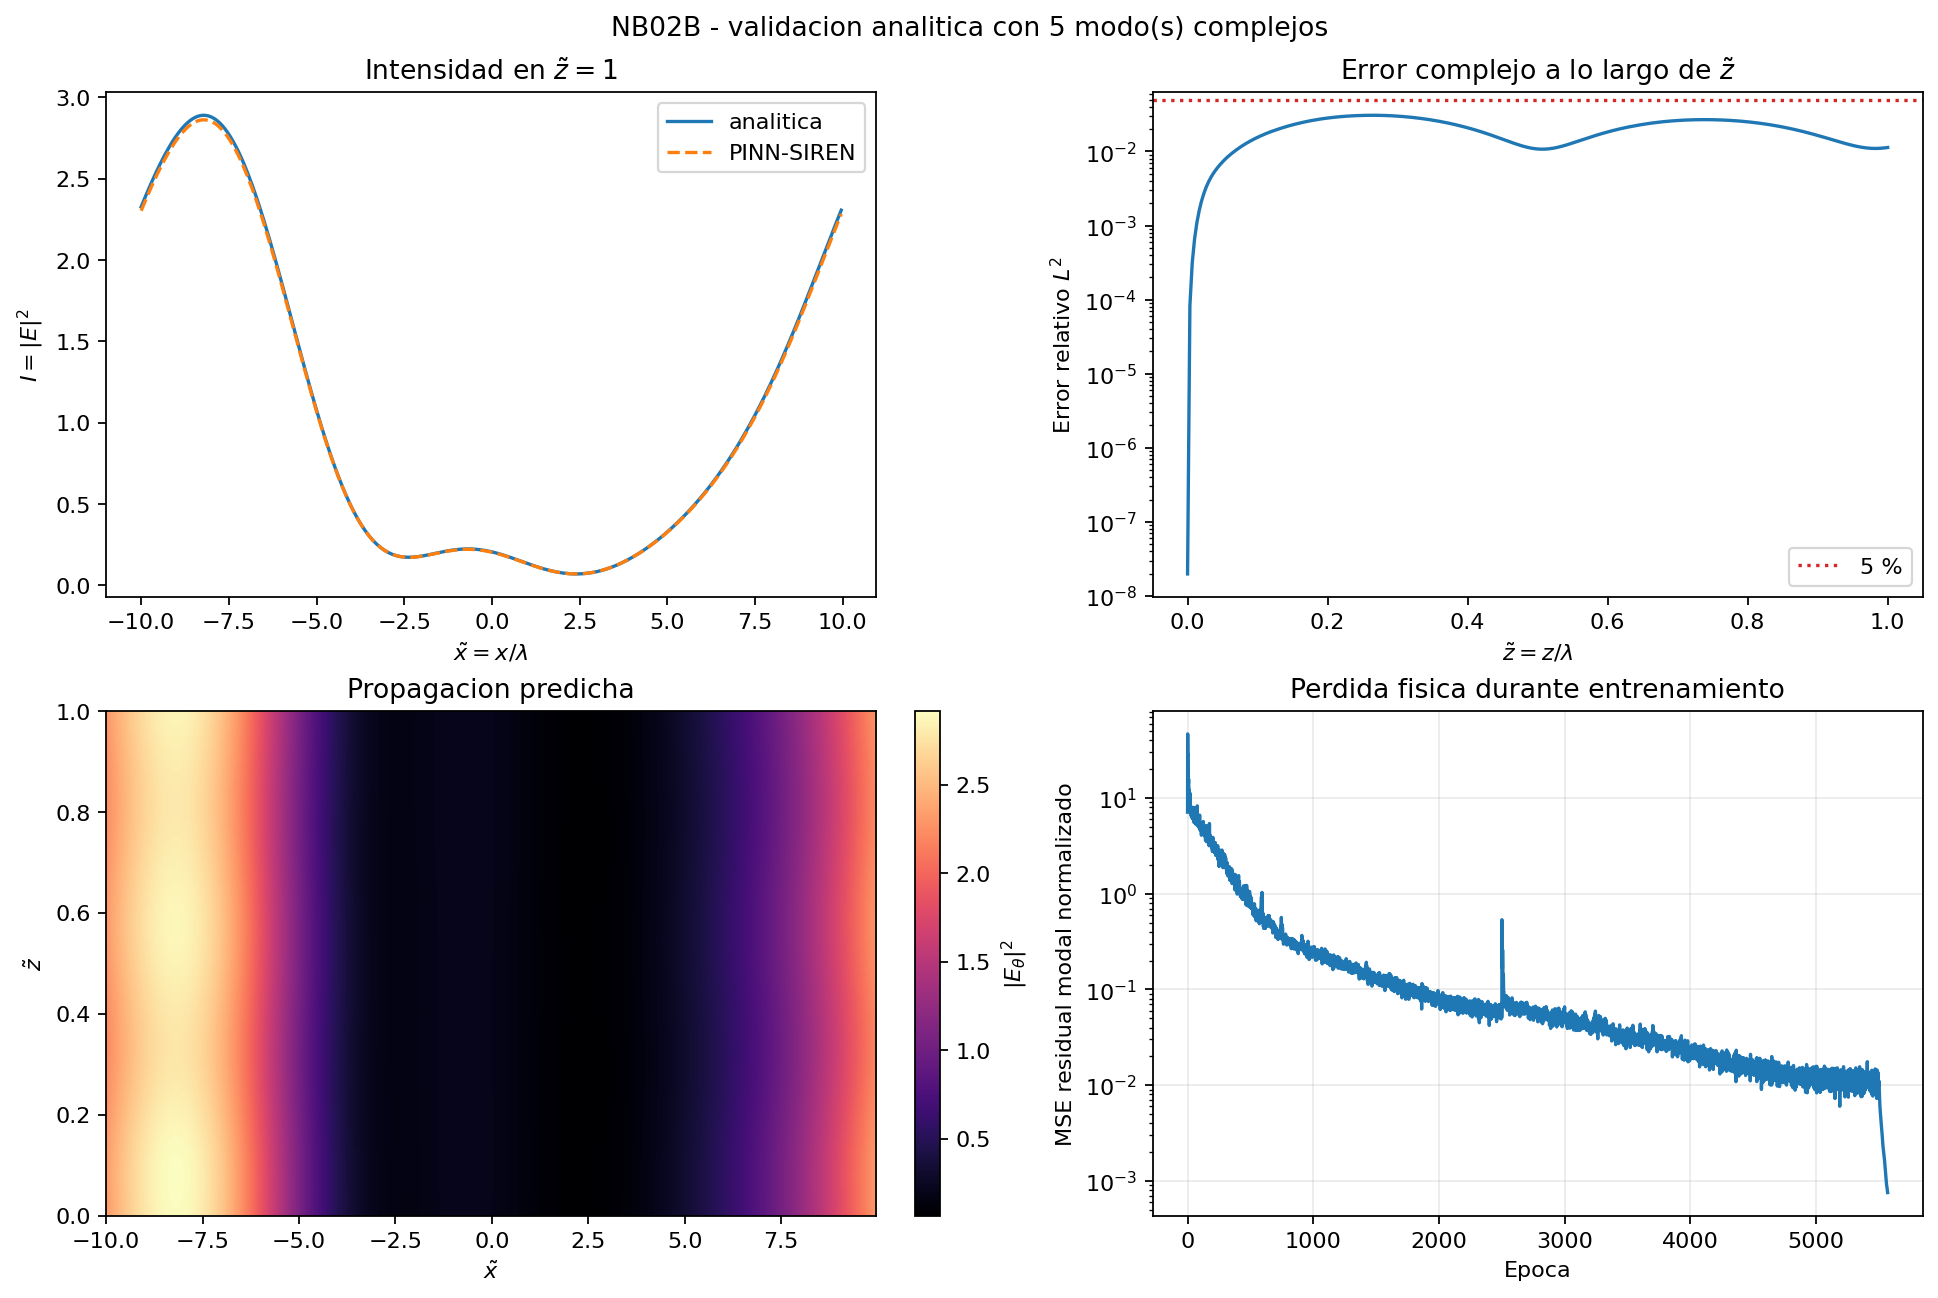

Caso: 41 modo(s)


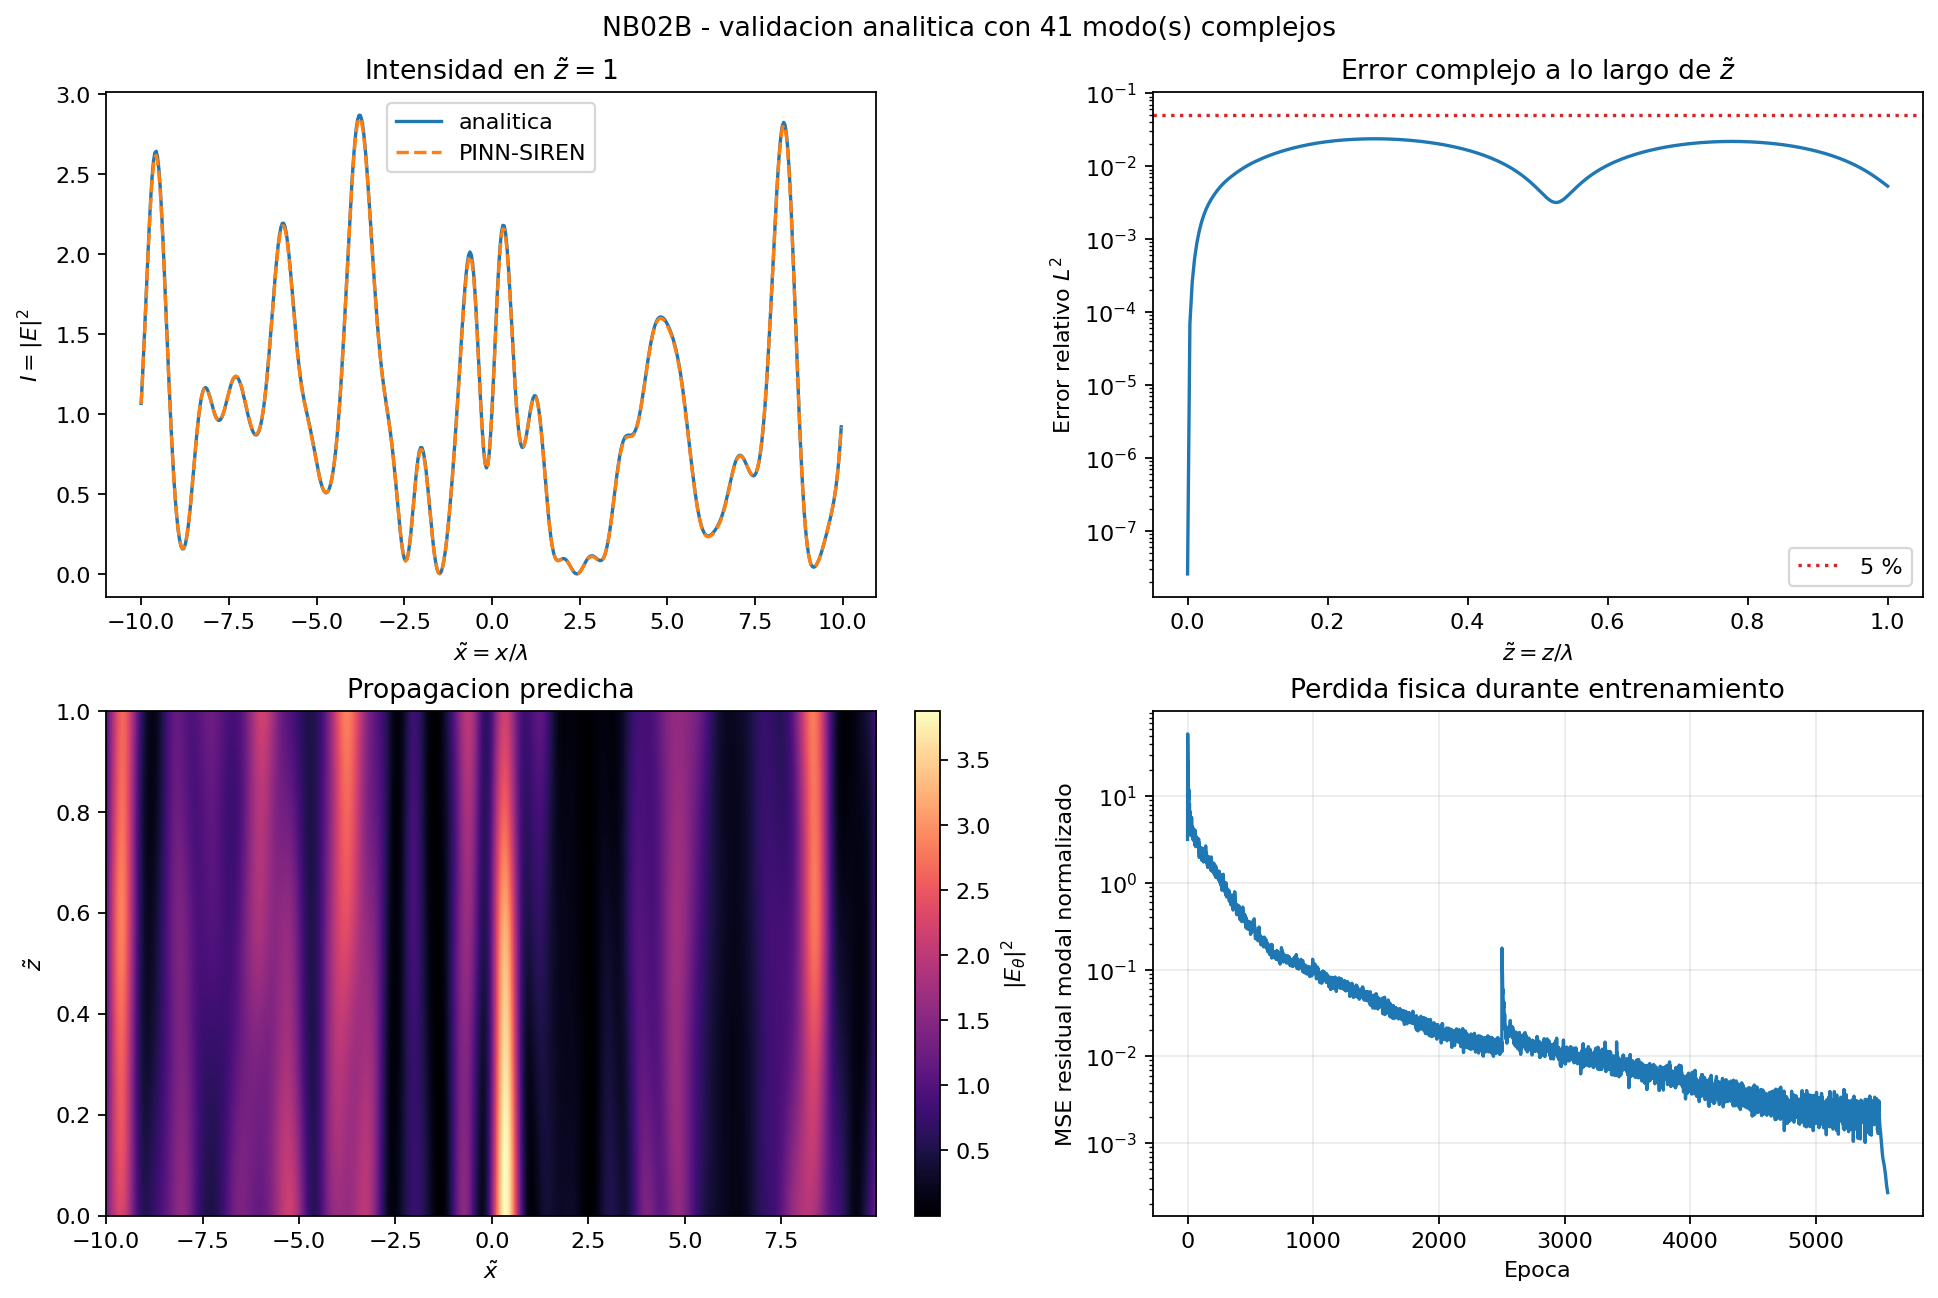

In [6]:
for count in (1, 5, 41):
    print(f'Caso: {count} modo(s)')
    display(Image(filename=str(RESULTS / 'figures' / f'case_{count:02d}_modes.png')))

## 8. Cómo interpretar el resultado

- Si pasan 1, 5 y 41 modos, la arquitectura modal está controlada y puede trasladarse con mayor confianza al campo aleatorio de NB03.
- Si pasa 1 modo pero falla 5, aparece una dificultad al representar simultáneamente frecuencias diferentes.
- Si pasan 1 y 5 pero falla 41, el cuello de botella está asociado a escala, capacidad o acondicionamiento multimodal.
- Si falla incluso 1 modo, debe revisarse la condición de Cauchy, la normalización del residuo, $\omega_0$ o el optimizador antes de tocar el speckle.

Esta lógica evita atribuir automáticamente al fenómeno aleatorio un error que podría proceder de la red.

In [7]:
passed = [
    case['n_complex_modes']
    for case in report['cases']
    if case['acceptance']['accepted']
]
failed = [
    case['n_complex_modes']
    for case in report['cases']
    if not case['acceptance']['accepted']
]
print(f'Casos aprobados: {passed}')
print(f'Casos no aprobados: {failed}')
print(f'Validación completa del puente: {report["all_cases_accepted"]}')

Casos aprobados: [1, 5, 41]
Casos no aprobados: []
Validación completa del puente: True


## 9. Alcance y siguiente decisión

NB02 continúa validando una PINN directa sobre $(\tilde x,\tilde y)$. NB02B valida la representación modal exacta empleada después sobre $(\tilde x,\tilde z)$. Son pruebas complementarias, no duplicadas.

Solo después de interpretar estos tres casos se debe decidir qué hiperparámetros, normalizaciones o estrategias de continuación trasladar a NB03. Los pesos entrenados aquí no sustituyen los de NB03 porque las amplitudes modales del speckle son diferentes.